<a href="https://colab.research.google.com/github/salma307/Text-Minning/blob/main/TP6_SALMA_HAFID_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP  Représentation du texte pour la classification de sentiments

  <table style="margin: 0 auto; color: white; font-size: 0.95em;">
    <tr><td style="padding:4px 20px;"><b>Établissement</b></td><td>ENSAM — Université Hassan II de Casablanca</td></tr>
    <tr><td style="padding:4px 20px;"><b>Année</b></td><td>2025 – 2026</td></tr>
    <tr><td style="padding:4px 20px;"><b>Cours</b></td><td>NLP — Traitement du Langage Naturel</td></tr>
    <tr><td style="padding:4px 20px;"><b>Dataset fil rouge</b></td><td>IMDb Movie Reviews (50 000 critiques)</td></tr>
    <tr><td style="padding:4px 20px;"><b>Tâche</b></td><td>Classification de sentiment : Positif / Négatif</td></tr>
  </table>

Ce notebook propose une mise en pratique progressive autour d’un problème classique de NLP : **classer des avis positifs ou négatifs à partir de leur texte**.

L’objectif pédagogique est double :
1. comprendre la logique des représentations textuelles ;
2. comparer, sur un même corpus, des approches de complexité croissante.

Vous pouvez travailler sur :
- **IMDb** (`IMDB Dataset of 50K Movie Reviews`) ;
    - https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

- ou un **corpus personnel** en classification supervisée.

Le travail suit une progression expérimentale :
**exploration → préparation → vectorisation → classification → évaluation → interprétation**.

### Conseils méthodologiques

Quelques principes à garder:
- une bonne représentation dépend de la tâche ;
- une meilleure représentation n’est pas toujours plus interprétable ;
- les gains de performance doivent être mis en regard du coût de calcul ;
- les erreurs observées sont souvent plus instructives que le score final.

### Librairies nécessaires
| Librairie | Rôle |
|-----------|------|
| `scikit-learn` | TF-IDF, BoW, métriques d'évaluation |
| `gensim` | Word2Vec, GloVe, FastText |
| `transformers` | BERT et modèles HuggingFace |
| `torch` | Backend pour BERT |
| `datasets` | Chargement du dataset IMDb depuis HuggingFace |
| `matplotlib / seaborn` | Visualisations |

In [4]:
#Installation (décommenter et exécuter une seule fois)
!pip install scikit-learn gensim transformers torch datasets
!pip install numpy pandas matplotlib seaborn umap-learn -q

In [5]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

random.seed(42)
np.random.seed(42)

## 1. Cadre expérimental

Avant toute modélisation, clarifiez le cadre de travail.

### Questions
- Quel corpus est utilisé ?
- Quelle est la variable cible ?
- Travaillez-vous sur l’ensemble du corpus ou sur un sous-échantillon ?
- Les classes sont-elles équilibrées ?

### Point méthodologique
Pour comparer plusieurs représentations, il est préférable de conserver **le même découpage apprentissage / test** pour toutes les expériences.

### Réponses:
- Quel corpus est utilisé ?
  #### =>Le dataset IMDb Movie Reviews
- Quelle est la variable cible ?
  #### => le label est ce que le text est positif ou negatif
- Travaillez-vous sur l’ensemble du corpus ou sur un sous-échantillon ?
  #### =>tous le corpus
- Les classes sont-elles équilibrées ?
  #### =>oui le nomres de text positif égale au nombres de text négatif

### Dataset IMDb Movie Reviews

#### Présentation du Dataset

Le dataset **IMDb Movie Reviews** est un référentiel standard du NLP pour l'analyse de sentiment.
Il contient **50 000 critiques de films en anglais**, équitablement réparties entre positif et négatif.

| Caractéristique | Valeur |
|-----------------|--------|
| Source | Internet Movie Database (IMDb) |
| Taille totale | 50 000 critiques |
| Entraînement | 25 000 (50% pos / 50% neg) |
| Test | 25 000 (50% pos / 50% neg) |
| Langue | Anglais |
| Tâche | Classification binaire : Positif (1) / Négatif (0) |
| Référence | Maas et al., 2011 — Stanford NLP |

#### Pourquoi ce dataset ?

Ce dataset est **idéal pour comparer les méthodes** car :
- Il contient de la **négation** : "not good", "not bad" → difficile pour BoW
- Il contient des **synonymes** : "excellent" ≈ "brilliant" → difficile pour TF-IDF
- Il contient des **mots rares et argotiques** → difficile pour Word2Vec
- Il nécessite une **compréhension du contexte** → BERT excelle ici
- Il est **bien équilibré** → métriques fiables

> **Pour faciliter l’expérimentation, vous pouvez travailler sur un sous‑ensemble du jeu de données (par exemple 10 000 à 20 000 exemples)**.

- Colonnes attendues :
    - text : le contenu textuel
    - label : la classe (0/1 ou autre encodage supervisé)

In [6]:
# Option A : charger IMDb depuis Hugging Face
#from datasets import load_dataset
# dataset = load_dataset("imdb")
# train_df = dataset["train"].to_pandas()
# test_df = dataset["test"].to_pandas()

# Option B : charger un fichier CSV local
df = pd.read_csv("/content/IMDB Dataset.csv")
df = df.rename(columns={"review": "text", "sentiment": "label"})
df.head()

,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Aide pour un corpus personnel

Si vous utilisez vos propres données, vérifiez que :
- chaque ligne correspond à un document ;
- le texte est bien dans une seule colonne ;
- l’étiquette de classe est disponible ;
- les valeurs manquantes ont été retirées ou traitées.

## 2. Exploration du corpus

### Objectifs
Observer la structure des données avant de les transformer,

> Une bonne exploration permet souvent d’anticiper les limites des représentations simples.

### Questions
- Combien de mots contiennent les avis, en moyenne ?
- Les textes sont-ils très hétérogènes en longueur ?
- Certaines classes utilisent-elles un vocabulaire plus “marqué” que d’autres ?
- Voyez-vous du bruit textuel utile à nettoyer ?

In [7]:
# Ajustez le nom du DataFrame selon votre cas
#df = train_df.copy()

df["length"] = df["text"].astype(str).str.split().apply(len)

display(df["length"].describe())
display(df.groupby("label")["length"].describe())

,length
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,25000.0,229.46456,164.947795,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.84932,177.497046,10.0,125.0,172.0,284.0,2470.0


### Réponses:
- Combien de mots contiennent les avis, en moyenne ?
  #### -> ils contiennent en moyenne environ 231 mots
- Les textes sont-ils très hétérogènes en longueur ?
  #### ->oui ils sont hétérogénes en longueur car il y a une grande différence entre le min et max et aussi l'ecart type est élevé par rapport à la moyenne

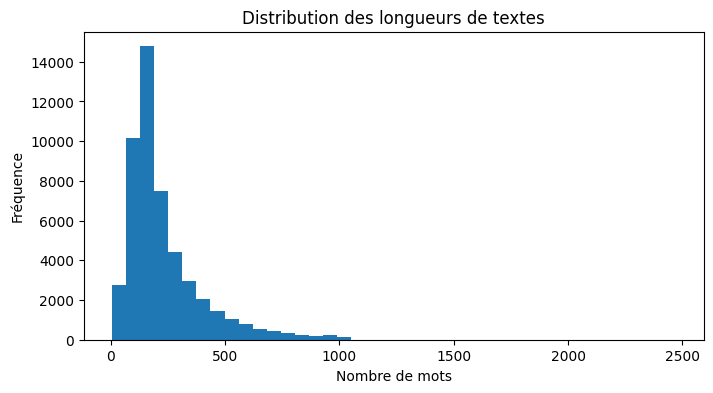

In [8]:
# Distribution des longueurs
plt.figure(figsize=(8, 4))
plt.hist(df["length"], bins=40)
plt.title("Distribution des longueurs de textes")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()

### Analyse à rédiger

Interpréter les principales observations :
- l’équilibre des classes ;
- la longueur des textes ;
- le niveau de bruit ;
- l’intérêt d’un sous-échantillon si le calcul devient trop coûteux.

## 3. Prétraitement

Le prétraitement doit être justifié. Dans une tâche de sentiment, certaines décisions peuvent être bénéfiques dans un contexte, et nuisibles dans un autre.

### Questions
- Faut-il supprimer les stopwords ?
- Faut-il conserver les négations comme `not`, `no`, `never` ?
- Faut-il conserver l’apostrophe et les contractions ?
- Faut-il normaliser l’écriture en minuscules ?

### Questions
- Faut-il supprimer les stopwords ?
  #### -> oui car il ne donne aucun information
- Faut-il conserver les négations comme `not`, `no`, `never` ?
  #### -> Oui car il importe une information si on a par exemple'not bad' = un sentiment positif si on supprime 'not' il devient 'bad'=sentiment négatif
- Faut-il conserver l’apostrophe et les contractions ?
  #### -> Oui car il donne un sens au mot comme " don't " si on les supprime "don t " ne donne aucun sens
- Faut-il normaliser l’écriture en minuscules ?
  #### -> oui pour diminuer la taille du dataset et eviter des doublons inutilies ' BAD '= 'bad'

### Point d’attention

Évitez de retirer automatiquement les mots de négation sans réflexion.  
Dans l’analyse de sentiment, cette décision peut supprimer une information essentielle.

In [9]:
def nettoyer_texte(texte: str) -> str:
    texte = str(texte).lower()
    texte = re.sub(r"<br\s*/?>", " ", texte)
    texte = re.sub(r"[^a-zA-Z\s']", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()
    return texte

df["text_clean"] = df["text"].apply(nettoyer_texte)
df[["text", "text_clean"]].head()

,text,text_clean
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei's love in the time of money is a...


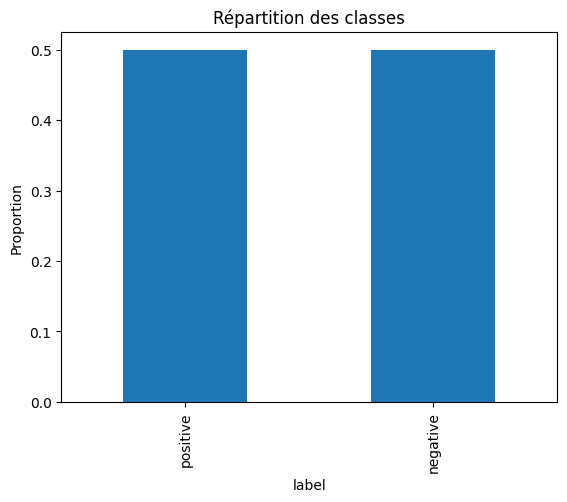

In [10]:
# Répartition des classes
df["label"].value_counts(normalize=True).plot(kind="bar")
plt.title("Répartition des classes")
plt.ylabel("Proportion")
plt.show()

## 4. Protocole de comparaison

Avant de tester les méthodes, mettez en place un cadre commun.

### À conserver constant
- le découpage train/test ;
- le classifieur de base ;
- les métriques ;
- le niveau de prétraitement.

### Pourquoi ?
Ainsi, les écarts observés proviennent principalement de la représentation textuelle, et non d’un changement de protocole.

In [11]:
# Variables de travail
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

## 5.  Bag of Words

Le Bag of Words transforme chaque texte en vecteur de fréquences lexicales.

### Questions
- Quelles informations conserve cette représentation ?
- Quelles informations perd-elle ?
- Pourquoi peut-elle rester performante sur IMDb ?
- Quels types d’erreurs peut-elle produire ?

### Réponses:
- Quelles informations conserve cette représentation ?
  #### ->cette représentation construit un vecteur pour chaque document dans lequelle il donne la pondération des mots dans un documents donc il garde deux information la présence de mots et sa fréquence
- Quelles informations perd-elle ?
  #### ->le contexte entre les mots , les synonymes ne sont pas identifié ,l'ordre des mots dans la phrases
- Pourquoi peut-elle rester performante sur IMDb ?
  #### -> les phrases sont longue (environ 231 mots par phrases) donc il peut capter plusieurs mots qui indique les sentiments
- Quels types d’erreurs peut-elle produire ?
  #### -> il ne peut pas interpreter la négation 'not good ' il va donner comme resultat positif

In [12]:
import time
bow_model = Pipeline([
    ("vect", CountVectorizer(max_features=10000)),
    ("clf", LogisticRegression(max_iter=1000))
])
start_train = time.time()
bow_model.fit(X_train, y_train)
end_train = time.time()
print(f"Temps d'entraînement : {end_train - start_train:.2f} secondes")
start_pred = time.time()
y_pred_bow = bow_model.predict(X_test)
end_pred = time.time()
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print("F1 macro:", f1_score(y_test, y_pred_bow, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_bow))

Temps d'entraînement : 67.89 secondes
Temps de prédiction : 1.88 secondes
Accuracy: 0.8834
F1 macro: 0.883399085848833
Confusion matrix:
 [[4403  597]
 [ 569 4431]]


In [13]:
# Coefficients les plus influents
vocab = bow_model.named_steps["vect"].get_feature_names_out()
coef = bow_model.named_steps["clf"].coef_[0]

top_pos = np.argsort(coef)[-10:]
top_neg = np.argsort(coef)[:10]

print("Mots les plus associés à la classe positive:")
print(vocab[top_pos])
print("\nMots les plus associés à la classe négative:")
print(vocab[top_neg])

Mots les plus associés à la classe positive:
['longoria' 'complaint' 'breed' 'compound' 'flawless' 'hilary' 'bimbo'
 'disappoint' 'stance' 'dismiss']

Mots les plus associés à la classe négative:
['waste' 'uninteresting' 'worst' 'disappointment' 'forgettable' 'lifeless'
 'disappointing' 'lacks' 'stinker' 'unremarkable']


### Interprétation guidée

Commentez les résultats en répondant à ces trois points :
1. Le modèle repère-t-il des mots sentimentaux explicites ?
2. Est-il sensible à l’ordre des mots ?
3. Que devient une phrase comme `not good` ?

### Interprétation :
1. Le modèle repère-t-il des mots sentimentaux explicites ?
    #### ->Oui
2. Est-il sensible à l’ordre des mots ?
    #### ->non il ne prend pas en compte l'ordre
3. Que devient une phrase comme `not good` ?
    #### -> il devient un vecteurs avec un ponderation 1 dans la dimension de 'not' et 'good' ca qui donne une iterpretation positif

## 6. N-grams

Les n-grams ajoutent une information partielle sur l’ordre local des mots.

### Questions
- Que gagne-t-on avec les bigrammes ?
- Pourquoi les trigrammes sont-ils souvent plus rares ?
- Quel compromis semble le plus pertinent entre précision et complexité ?

### Réponses:
- Que gagne-t-on avec les bigrammes ?
  #### -> Les bigrammes peut prendre en considération la négation
- Pourquoi les trigrammes sont-ils souvent plus rares ?
  #### ->car il prend beaucoup de mémoire parceque les vecteurs sont plus long et il peut fausser le résultat car une combinaison de trois mots apparait peu de fois d'ou risque de overfitting et de bruit
- Quel compromis semble le plus pertinent entre précision et complexité ?
  #### ->une précision elevée avec une faible complexité (temps court et pas de grand memoire)

In [14]:
ngram_model = Pipeline([
    ("vect", CountVectorizer(max_features=15000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

ngram_model.fit(X_train, y_train)
y_pred_ng = ngram_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_ng))
print("F1 macro:", f1_score(y_test, y_pred_ng, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_ng))

Accuracy: 0.8881
F1 macro: 0.8880993006206288
Confusion matrix:
 [[4428  572]
 [ 547 4453]]


### À observer

Cherchez des expressions fréquentes comme :
- `not good`
- `really bad`
- `highly recommend`
- `waste of time`

Demandez-vous si le modèle les traite mieux que BoW.

In [15]:
vocabulaire = ngram_model.named_steps["vect"].vocabulary_
expressions = ["not good", "really bad", "highly recommend", "waste of time"]

for expr in expressions:
    if expr in vocabulaire:
        print(f'"{expr}" est présent dans le vocabulaire de bigrammes')
    else:
        print(f'"{expr}" n’est pas présent dans le vocabulaire de bigrammes')

"not good" est présent dans le vocabulaire de bigrammes
"really bad" est présent dans le vocabulaire de bigrammes
"highly recommend" est présent dans le vocabulaire de bigrammes
"waste of time" n’est pas présent dans le vocabulaire de bigrammes


### => les trois premier sont présent mais le dernier "waste of time" non car il est composer de trois mots

In [16]:
for expr in expressions:
    if expr in vocab:
        print(f'"{expr}" est présent dans le vocabulaire de BOW')
    else:
        print(f'"{expr}" n’est PAS présent dans le vocabulaire de BOW')

"not good" n’est PAS présent dans le vocabulaire de BOW
"really bad" n’est PAS présent dans le vocabulaire de BOW
"highly recommend" n’est PAS présent dans le vocabulaire de BOW
"waste of time" n’est PAS présent dans le vocabulaire de BOW


### => les mots ne sont pas présent dans le vocabulaire de BOW ce qui confirme que BOW ne prend pas en considération la négation d'ou il fausse les resultats dans des phrases contenant ces dernier d'ou bigrammes traite mieux que BOW

## 7. TF-IDF

TF-IDF corrige la simple fréquence par une pondération liée à la rareté du terme dans le corpus.

### Questions
- Quels mots sont naturellement pénalisés ?
- Pourquoi TF-IDF est-il souvent supérieur à BoW ?
- Dans quels cas la différence peut-elle rester faible ?

### Réponses:
- Quels mots sont naturellement pénalisés ?
  #### ->les mots rares(tf (fréquences dans le document) petite) les mots courants(idf (l'importance selon le corpus) faible)
- Pourquoi TF-IDF est-il souvent supérieur à BoW ?
  #### ->car il prend en consideration la fréquences et la rareté des mots il donne aux mots informatifs plus d'importance tandis que BOW donne l'importance aux fréquances brut
- Dans quels cas la différence peut-elle rester faible ?
  #### ->si le text contient déja beaucoup de mots clé donc BOW les captent ou si on a deja eleminer les mots peu informatifs

In [17]:
tfidf_model = Pipeline([
    ("vect", TfidfVectorizer(max_features=15000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])
start_train = time.time()
tfidf_model.fit(X_train, y_train)
end_train = time.time()
print(f"Temps d'entraînement : {end_train - start_train:.2f} secondes")
start_pred = time.time()
y_pred_tfidf = tfidf_model.predict(X_test)
end_pred = time.time()
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print("F1 macro:", f1_score(y_test, y_pred_tfidf, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_tfidf))

Temps d'entraînement : 49.27 secondes
Temps de prédiction : 5.14 secondes
Accuracy: 0.9034
F1 macro: 0.9033957919206961
Confusion matrix:
 [[4484  516]
 [ 450 4550]]


### Question d’analyse

TF-IDF est-il meilleur parce qu’il “comprend” mieux le texte, ou parce qu’il réduit le poids des mots peu informatifs ?  
Justifiez votre réponse.

### => tf-idf est meilleur parce qu’il réduit le poids des mots peu informatifs n'est pas parce qu’il “comprend” mieux le texte car il ne prend pas en consequences le contexte des mots dans les phrases il ne comprend ni le sens ni la relation entre les mots
#### par exemple:
##### "not good" le TF-IDF ne comprend pas que c’est négatif, il compte juste "not" et "good" avec leurs pondérations et si on l'utilise avec bigrammes il va donner des résultats juste pas parceque il comprend le contexte mais grace aux bigrammes

## 8. Comparaison des méthodes lexicales

À ce stade, comparez :
- Bag of Words ;
- N-grams ;
- TF-IDF.

### Questions de conclusion
- Quelle méthode offre le meilleur compromis ?
- La meilleure performance est-elle forcément la plus simple à interpréter ?
- Quelle méthode recommanderiez-vous dans un contexte de déploiement rapide ?

In [18]:
# Tableau à compléter
resultats_lexicaux = pd.DataFrame([
    {"Méthode": "BoW", "Accuracy": 0.8834, "F1_macro": 0.883399085848833},
    {"Méthode": "N-grams", "Accuracy": 0.8881, "F1_macro": 0.8880993006206288},
    {"Méthode": "TF-IDF", "Accuracy": 0.9034, "F1_macro": 0.9033957919206961},
 ])

display(resultats_lexicaux.sort_values("Accuracy", ascending=True))

,Méthode,Accuracy,F1_macro
0,BoW,0.8834,0.883399
1,N-grams,0.8881,0.888099
2,TF-IDF,0.9034,0.903396


### Reponses:
Quelle méthode offre le meilleur compromis ?
 #### ->tf-idf car il combine meilleure compromis précision et complexité
La meilleure performance est-elle forcément la plus simple à interpréter ?
 #### ->Non car BOW est le mois perfmant ici mais il est le plus simple à interpreter chaque dimension = la ponderation du mot
Quelle méthode recommanderiez-vous dans un contexte de déploiement rapide ?
 #### ->pour la rapidité et une faible consommation de memoire on peut utiliser BOW ou N-grams (mais avec une dataset simple pour meilleure performance) si on veut meilleures perfermonces on utilisent Tf-idf mais si le dataset est grand il va etre plus lent


## 9. Word Embeddings — Word2Vec

Un embedding dense représente un mot dans un espace vectoriel continu.

### Questions
- Que signifie une proximité entre deux mots dans cet espace ?
- Pourquoi un embedding peut-il capturer de la similarité sémantique ?
- Que perd-on lorsqu’on résume un document par la moyenne de ses vecteurs de mots ?

### Réponses:
- Que signifie une proximité entre deux mots dans cet espace ?
  #### ->dans Word2Vec les mots sont represents par des vecteurs denses une proximité entre deux mots dans cet espace signifie que leur representation est proches donc ils ont un sens proches
- Pourquoi un embedding peut-il capturer de la similarité sémantique ?
  #### ->car les mots qui apparaissent souvant dans des contextes similaires ont des vecteurs proches.
- Que perd-on lorsqu’on résume un document par la moyenne de ses vecteurs de mots ?
  #### ->l'ordre des mots et le contexte

In [19]:
from gensim.models import Word2Vec

sentences = [str(t).split() for t in df["text_clean"]]
w2v = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

> **Visualiser l’espace vectoriel des mots en utilisant t-SNE**


In [20]:
from sklearn.manifold import TSNE

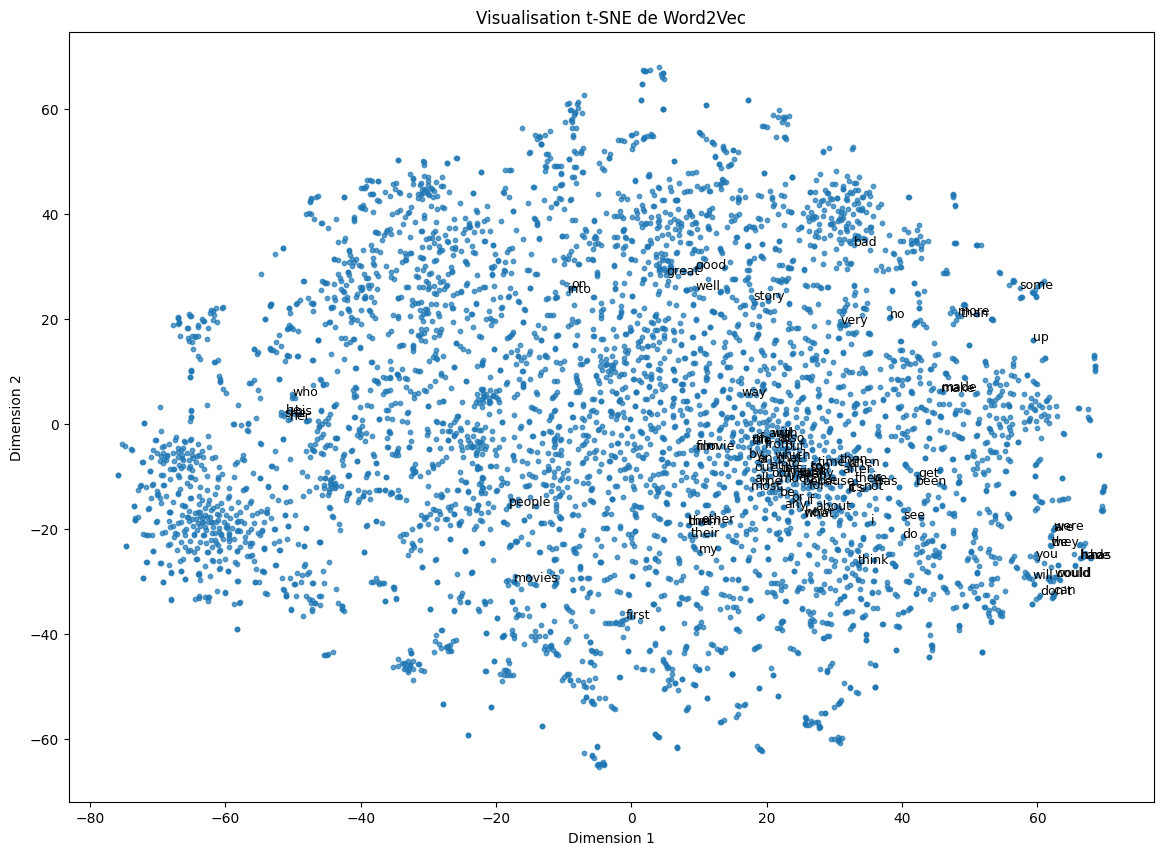

In [21]:
words = list(w2v.wv.key_to_index.keys())[:5000]
word_vectors = w2v.wv[words]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init='pca',
    learning_rate='auto'
)
word_vecs_2d = tsne.fit_transform(word_vectors)

df_tsne = pd.DataFrame(word_vecs_2d, columns=["x", "y"])
df_tsne["word"] = words

plt.figure(figsize=(14,10))
plt.scatter(df_tsne["x"], df_tsne["y"], s=10, alpha=0.7)

for i, word in enumerate(df_tsne["word"][:100]):
    plt.text(df_tsne["x"][i], df_tsne["y"][i], word, fontsize=9)

plt.title("Visualisation t-SNE de Word2Vec")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

In [22]:
def document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.vstack([
    document_vector(str(t).split(), w2v, 100)
    for t in df["text_clean"]
])

In [23]:
# Classification sur les vecteurs Word2Vec
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
     X_w2v, y, test_size=0.2, random_state=42, stratify=y
 )

clf_w2v = LogisticRegression(max_iter=1000)
start_train = time.time()
clf_w2v.fit(X_train_w2v, y_train)
end_train = time.time()
print(f"Temps d'entraînement : {end_train - start_train:.2f} secondes")
start_pred = time.time()
y_pred_w2v = clf_w2v.predict(X_test_w2v)
end_pred = time.time()
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print("Accuracy:", accuracy_score(y_test, y_pred_w2v))
print("F1 macro:", f1_score(y_test, y_pred_w2v, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_w2v))

Temps d'entraînement : 0.97 secondes
Temps de prédiction : 0.03 secondes
Accuracy: 0.8647
F1 macro: 0.8646986997545046
Confusion matrix:
 [[4339  661]
 [ 692 4308]]


### Interprétation guidée

Comparez Word2Vec à TF-IDF :
- Word2Vec apprend-il mieux le sens global ?
- La moyenne des mots est-elle suffisante pour une tâche de sentiment ?
- Les mots rares sont-ils bien représentés ?
- Pourquoi les résultats peuvent-ils rester proches, voire inférieurs, à TF-IDF ?

### Interprétation:
- Word2Vec apprend-il mieux le sens global ?
    #### ->oui car Word2Vec encode les relations sémantiques et contextuelles entre mots tandis que TF-IDF ne fait que pondérer des mots selon leur fréquence inverse du corpus, sans capturer de relations entre mots.
- La moyenne des mots est-elle suffisante pour une tâche de sentiment ?
    #### ->Pour des phrases simples oui mais il ne prend pas en considération l'ordre "not good" ≈ "good not" mais TF-IDF souvent plus efficace sur IMDb car il pondère les mots discriminants.
- Les mots rares sont-ils bien représentés ?
    #### ->Dans Word2Vec les mots rares ne sont pas appris selon le min_count mais dans Tf-idf les mots rares on généralement un poids élevé
- Pourquoi les résultats peuvent-ils rester proches, voire inférieurs, à TF-IDF ?
    #### ->Car word2vect capture plus la sémentique mais perd la fréquences la rareté et la négation tandis que simple mais souvent très efficace pour la classification de texte.

## 10. FastText

FastText enrichit Word2Vec en intégrant des sous-mots.

### Questions
- En quoi cela aide-t-il pour les mots rares ?
- Pourquoi FastText est-il souvent plus robuste aux fautes d’orthographe ?
- Dans quelles langues cette propriété est-elle particulièrement utile ?

### Réponses:
- En quoi cela aide-t-il pour les mots rares ?
    #### ->FastText décompose les mots en n-grammes donc meme si le mots et rare ses n-grammes apparaissent dans d'autres mots plus fréquents donc la sommes de fréquences des n-grammes donne une fréquence pour le mot plus élevée
- Pourquoi FastText est-il souvent plus robuste aux fautes d’orthographe ?
    #### ->car il decompose le mots en n-grammes donc meme si il ya un oov le vecteur de mots faur partage plusieurs n-grammes avec le mots correctes
- Dans quelles langues cette propriété est-elle particulièrement utile ?
    #### ->Dans les langues à morphologie riche, où un radical peut avoir de nombreuses terminaisons

In [24]:
from gensim.models import FastText

ft = FastText(sentences=sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

In [25]:
def get_doc_vector(doc, model):
    vecs = [model.wv[word] for word in doc if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

X_ft = np.array([get_doc_vector(text.split(), ft) for text in df["text_clean"]])

In [26]:
X_train_ft, X_test_ft, y_train, y_test = train_test_split(
    X_ft, y, test_size=0.2, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=1000)
start_train = time.time()
clf.fit(X_train_ft, y_train)
end_train = time.time()
print(f"Temps d'entraînement : {end_train - start_train:.2f} secondes")
start_pred = time.time()
y_pred = clf.predict(X_test_ft)
end_pred = time.time()
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Temps d'entraînement : 1.11 secondes
Temps de prédiction : 0.01 secondes
Accuracy: 0.8653
F1 macro: 0.865299610715875
Confusion matrix:
 [[4335  665]
 [ 682 4318]]


### Comparaison attendue

FastText est-il plus performant parce qu’il comprend mieux les émotions, ou parce qu’il gère mieux les formes inconnues et les variantes morphologiques ?  
Répondez en vous appuyant sur l’observation des corpus.

### => FastText est plus performant dans les corpus réels principalement grâce à sa gestion des mots rares, variantes morphologiques et fautes d’orthographe, pas parce qu’il comprend mieux les émotions
### Word2Vec attribue un vecteur uniquement si le mot est connu dans le corpus. Les mots rares ou mal orthographiés sont OOV FastText lui construit le vecteur à partir des n‑grammes de caractères donc même un mot rare ou mal orthographié a un vecteur proche de ses variantes ou du radical.

## 11. Embeddings contextuels — BERT

BERT produit des vecteurs dépendants du contexte. Un mot n’a donc plus un seul vecteur fixe.

### Questions
- Pourquoi la négation est-elle mieux traitée ?
- Pourquoi BERT distingue-t-il mieux les contextes ?
- Qu’apporte le contexte bidirectionnel par rapport à un embedding statique ?

### Réponses:
Pourquoi la négation est-elle mieux traitée ?
   #### ->Car Bert prend en considération le contexte des phrases il donne au not good un vecteur différent à good
Pourquoi BERT distingue-t-il mieux les contextes ?
   #### ->Car Bert prend en compte les mots qui change de sens selon la phrases pour chaque sens il donne un vecteurs différent
Qu’apporte le contexte bidirectionnel par rapport à un embedding statique ?
   #### ->il encode le mot en tennant compte des mosts qui le précedent etble suivent dans la phrase

In [27]:
from transformers import AutoTokenizer, AutoModel

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
def bert_embeddings(texts, tokenizer, model, max_length=256, batch_size=16):
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            out = model(**enc)

        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_emb.append(cls_emb)

    return np.vstack(all_emb)

In [ ]:
import torch
texts = df["text_clean"].tolist()
device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model.to(device)
X_bert = bert_embeddings(texts, tokenizer, bert_model)
print(X_bert.shape)

X_train_bert, X_test_bert, _, _ = train_test_split(
     X_bert, y, test_size=0.2, random_state=42, stratify=y
 )

clf_bert = LogisticRegression(max_iter=1000)
start_train = time.time()
clf_bert.fit(X_train_bert, y_train)
end_train = time.time()
print(f"Temps d'entraînement : {end_train - start_train:.2f} secondes")
start_pred = time.time()
y_pred_bert = clf_bert.predict(X_test_bert)
end_pred = time.time()
print(f"Temps de prédiction : {end_pred - start_pred:.2f} secondes")
print("Accuracy:", accuracy_score(y_test, y_pred_bert))
print("F1 macro:", f1_score(y_test, y_pred_bert, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_bert))

### Variante pédagogique

Pour limiter le coût de calcul, appliquez BERT sur un sous-échantillon raisonnable du corpus, puis comparez les tendances obtenues avec les méthodes précédentes.

## 12. Évaluation commune

Utilisez les mêmes métriques pour toutes les méthodes testées.

### Métriques recommandées
- accuracy ;
- F1 macro ;
- matrice de confusion.

### Questions
- Quelle métrique reste la plus informative si les classes sont déséquilibrées ?
- Que révèle la matrice de confusion sur les types d’erreurs ?

### Réponses:
Quelle métrique reste la plus informative si les classes sont déséquilibrées ?
#### ->F1-score macro reste fiable, car elle pèse toutes les classes de manière égale, contrairement à l’accuracy qui peut être biaisée par la classe majoritaire.Dans les cas extrêmes l’accuracy peut donner une illusion de performance alors que le modèle ignore complètement la minorité.
Que révèle la matrice de confusion sur les types d’erreurs ?
#### ->Quels types d’erreurs le modèle fait :Est-il plus conservateur (prédit rarement la classe minoritaire) ? et Commet-il plus de faux positifs ou de faux négatifs ?

In [ ]:
def evaluer(y_true, y_pred, nom="Modèle"):
    print(f"--- {nom} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("F1 macro :", round(f1_score(y_true, y_pred, average="macro"), 4))
    print(classification_report(y_true, y_pred))

In [ ]:
#Matrice de confusion
cm = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(4, 4))
plt.imshow(cm, interpolation='nearest')
plt.title("Matrice de confusion")
plt.colorbar()
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

## 13. Analyse des erreurs

L’analyse des erreurs est une étape essentielle.

### À faire
Repérez quelques exemples :
- faux positifs ;
- faux négatifs ;
- cas ambigus ;
- textes contenant de la négation ;
- textes très courts ou très longs.

### Questions
- Les erreurs sont-elles aléatoires ?
- Les méthodes lexicales échouent-elles sur les mêmes cas que les embeddings ?
- BERT corrige-t-il vraiment les ambiguïtés observées plus tôt ?

## 14. Tableau comparatif final

Complétez un tableau récapitulatif avec vos résultats expérimentaux.

### Colonnes conseillées
- Méthode
- Type de représentation
- Accuracy
- F1 macro
- Temps d’exécution
- Avantages
- Limites

In [ ]:
# Exemple de structure à compléter
resultats = pd.DataFrame([
     {"Méthode": "BoW", "Type": "Lexicale", "Accuracy": 0.8834, "F1_macro": 0.883399085848833, "Temps": 67.89},
     {"Méthode": "TF-IDF", "Type": "Lexicale pondérée", "Accuracy": 0.9034, "F1_macro": 0.9033957919206961, "Temps": 49.27},
     {"Méthode": "Word2Vec", "Type": "Embedding statique", "Accuracy": 0.8647, "F1_macro": 0.8646986997545046, "Temps": 0.97},
     {"Méthode": "FastText", "Type": "Embedding sous-mots", "Accuracy": 0.8653, "F1_macro": 0.865299610715875, "Temps": 1.11},
     {"Méthode": "BERT", "Type": "Embedding contextuel", "Accuracy": ..., "F1_macro": ..., "Temps": ...},
 ])
display(resultats)

## 15. Questions de synthèse

Rédigez une synthèse courte et structurée.

### À discuter
- Quelle méthode vous semble la plus adaptée à votre corpus ?
- La meilleure méthode est-elle la plus simple à interpréter ?
- Quel compromis choisiriez-vous entre précision, coût de calcul et explicabilité ?
- Si vous disposiez de plus de données, le classement des méthodes changerait-il selon vous ?